# Customer Churn Analysis

## Problem
Customer churn leads to revenue loss. Identifying churn drivers helps improve retention.

## Objective
Analyze customer data to identify key factors affecting churn and provide business recommendations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"D:\Projects\Churn analysis\data/Customer_churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Understanding

In [3]:
df.shape

(7043, 21)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


- Dataset contains 7043 rows and 21 columns  
- Target variable is **Churn**  
- Majority of features are categorical  
- Numerical features include tenure, MonthlyCharges, TotalCharges  

## Data Cleaning

In [6]:
# find the missing values or blank values
df[df["TotalCharges"] == ""]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [7]:
# reaplacing missing value with 0 as tenue is 0
df["TotalCharges"] = df["TotalCharges"].replace(" ","0")

In [8]:
# converting datatype to float
df["TotalCharges"] = df["TotalCharges"].astype("float")

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [10]:
df.isnull().sum().sum()

np.int64(0)

In [11]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [12]:
df["customerID"].duplicated().sum()

np.int64(0)

In [13]:
# converting SeniorCitizen values to yes or no from 1 and 0

def convt(value):
    if value == 0:
        return "no"
    else:
        return "yes"

df["SeniorCitizen"] = df["SeniorCitizen"].apply(convt)
    

## Target Variable Analysis

In [14]:
df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

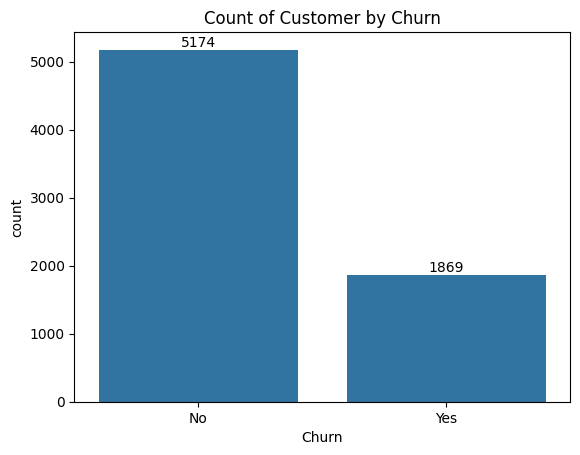

In [15]:
# counting total no. of churns

ax = sns.countplot(data = df, x = "Churn")

ax.bar_label(ax.containers[0])
plt.title("Count of Customer by Churn")
plt.show()

- Around 27% of customers have churned, while ~73% are retained  
- This indicates a moderate churn problem that requires attention  

## Demographic Analysis

<Axes: xlabel='gender', ylabel='count'>

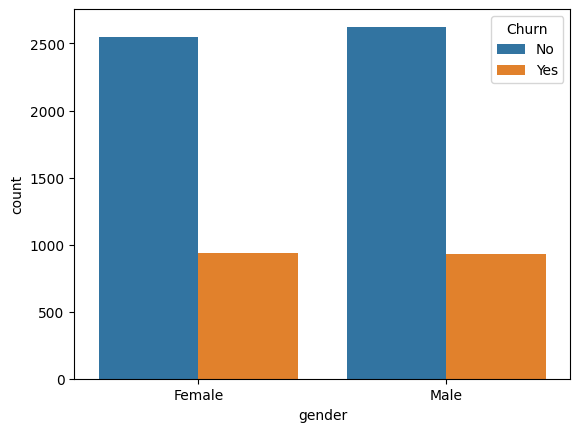

In [16]:
# Gender
sns.countplot(data=df, x='gender', hue='Churn')

In [17]:
pd.crosstab(df['gender'], df['Churn'], normalize='index') * 100

Churn,No,Yes
gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


- Female customers show ~26.9% churn compared to ~26.2% for male customers  
- The churn rate is nearly identical across genders, indicating no significant impact  
- This suggests that retention strategies should not be differentiated based on gender  

<Axes: xlabel='SeniorCitizen', ylabel='count'>

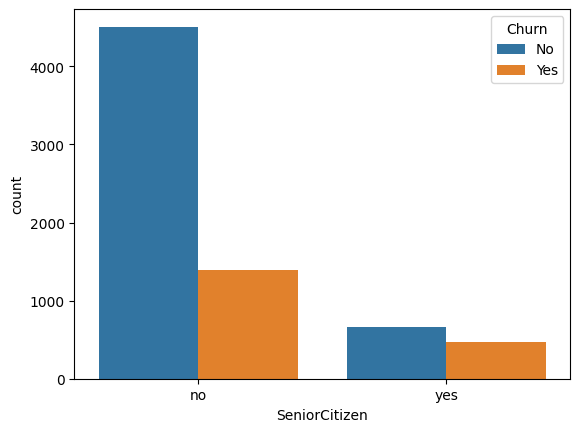

In [18]:
# Senier Citizen
sns.countplot(data=df, x='SeniorCitizen', hue='Churn')

- Senior citizens show a higher churn rate compared to non-senior customers  
- This indicates older customers are more likely to discontinue services  
- The company should design targeted retention strategies for senior users  

<Axes: xlabel='Partner', ylabel='count'>

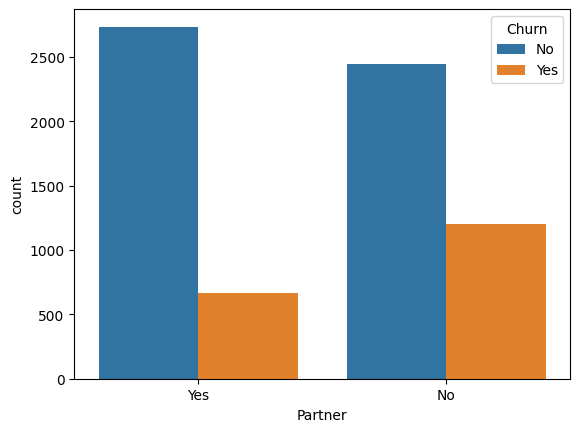

In [19]:
# Partner
sns.countplot(data=df, x='Partner', hue='Churn')

In [20]:
pd.crosstab(df['Partner'], df['Churn'], normalize='index') * 100

Churn,No,Yes
Partner,,
No,67.042021,32.957979
Yes,80.335097,19.664903


- Customers without a partner show ~33.0% churn compared to ~19.7% for those with a partner  
- This indicates that partnered customers are significantly more likely to stay (~1.7x lower churn)  
- Customers without partners represent a higher-risk segment and can be targeted with personalized retention offers   

<Axes: xlabel='Dependents', ylabel='count'>

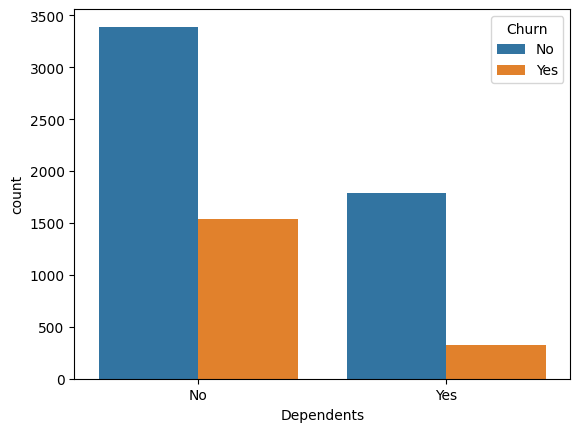

In [21]:
# Dependents
sns.countplot(data=df, x='Dependents', hue='Churn')

- Customers without dependents tend to churn more frequently  
- Customers with dependents may rely more on the service, leading to lower churn  
- Retention efforts can focus more on independent users  

In [22]:
pd.crosstab(df['SeniorCitizen'], df['Churn'], normalize='index') * 100

Churn,No,Yes
SeniorCitizen,,
no,76.393832,23.606168
yes,58.318739,41.681261


- Senior citizens have ~41.7% churn compared to ~23.6% for non-senior customers  
- This indicates that senior customers are significantly more likely to churn  
- Targeted retention strategies for senior users could help reduce overall churn  

## Service-Based Analysis

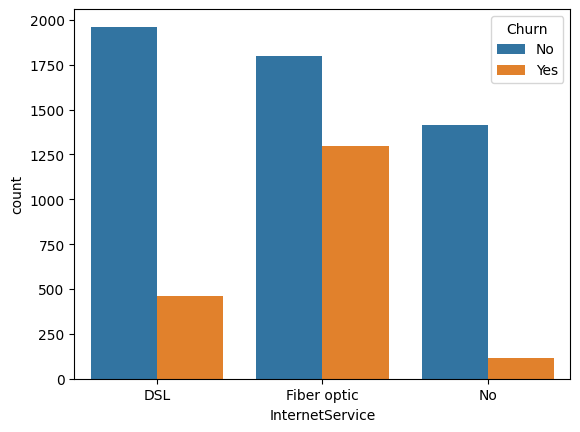

In [23]:
# Internet Service
sns.countplot(data=df, x='InternetService', hue='Churn')
plt.savefig("internet_churn.png")

- Fiber optic users show significantly higher churn compared to DSL users  
- This suggests possible issues with pricing, service quality, or expectations  
- Improving fiber service experience could reduce churn significantly  

<Axes: xlabel='OnlineSecurity', ylabel='count'>

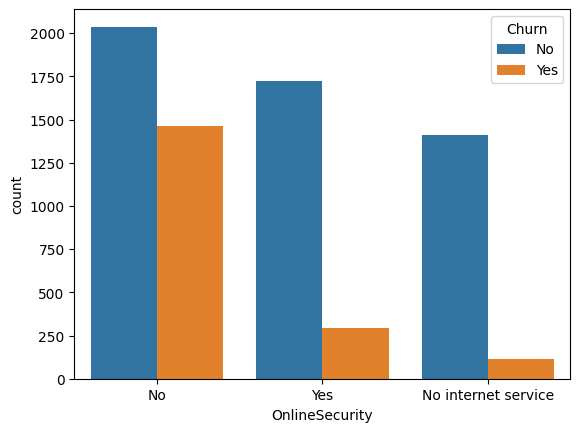

In [24]:
# Online Security
sns.countplot(data=df, x='OnlineSecurity', hue='Churn')

- Customers without online security exhibit much higher churn  
- This indicates that security services play a key role in customer retention  
- Promoting or bundling this service can reduce churn  

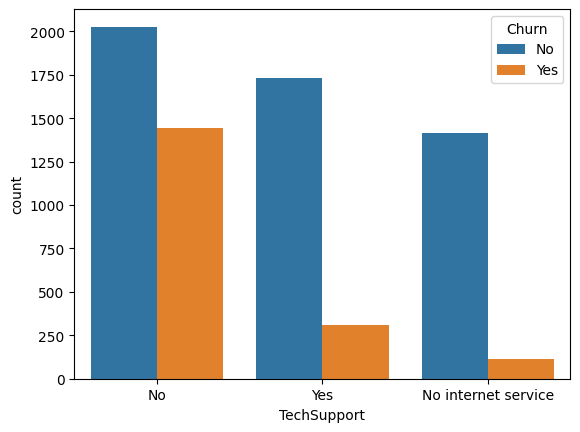

In [25]:
# Tech Support
sns.countplot(data=df, x='TechSupport', hue='Churn')
plt.savefig("techsupport_churn.png")

- Customers without tech support have significantly higher churn rates  
- Access to support improves customer satisfaction and retention  
- Upselling tech support services could be a high-impact strategy  

<Axes: xlabel='StreamingTV', ylabel='count'>

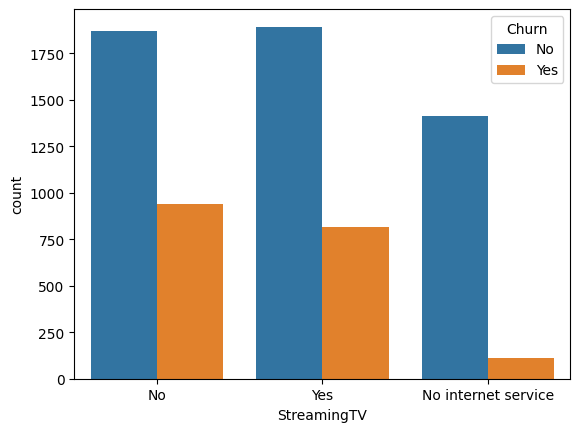

In [26]:
# Streaming Tv
sns.countplot(data=df, x='StreamingTV', hue='Churn')

- Customers without streaming services tend to churn more  
- Streaming increases engagement but has moderate impact  
- Bundling entertainment services can improve retention  

<Axes: xlabel='StreamingMovies', ylabel='count'>

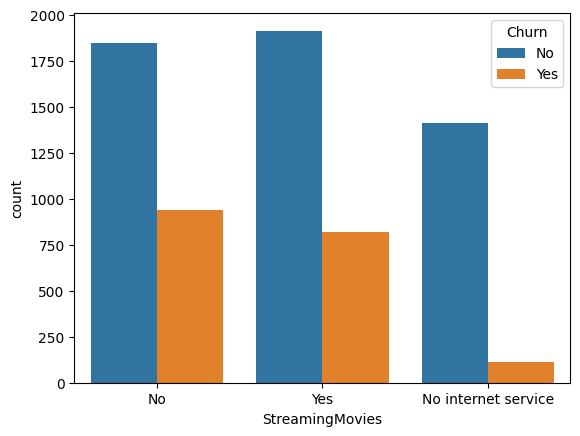

In [27]:
# Streaming Movies
sns.countplot(data=df, x='StreamingMovies', hue='Churn')

- Similar trend as StreamingTV, with lower churn among users who use the service  
- Indicates engagement-based retention effect  

In [28]:
pd.crosstab(df['TechSupport'], df['Churn'], normalize='index') * 100

Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


- Customers without TechSupport have ~41.6% churn compared to ~15.2% for those with TechSupport  
- This shows that lack of technical support significantly increases churn risk (~2.7x higher)  
- Providing or bundling TechSupport can be a highly effective strategy to improve customer retention  

## Account Analysis

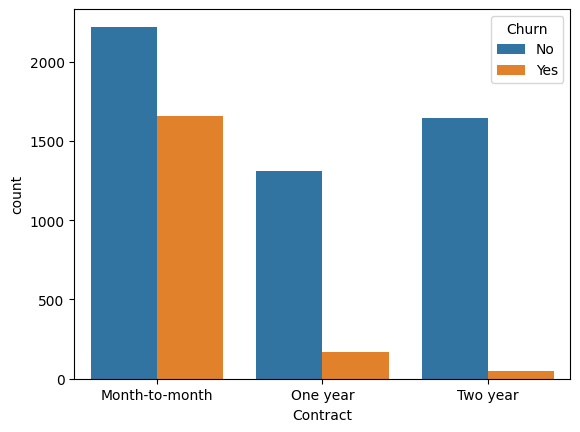

In [29]:
# Contract
sns.countplot(data=df, x='Contract', hue='Churn')
plt.savefig("contract_churn.png")  

In [30]:
pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


- Customers with month-to-month contracts have ~42.7% churn, significantly higher than one-year (~11.3%) and two-year (~2.8%) contracts  
- This shows that longer contract commitments greatly improve customer retention  
- Encouraging customers to switch from monthly to long-term contracts can significantly reduce churn  

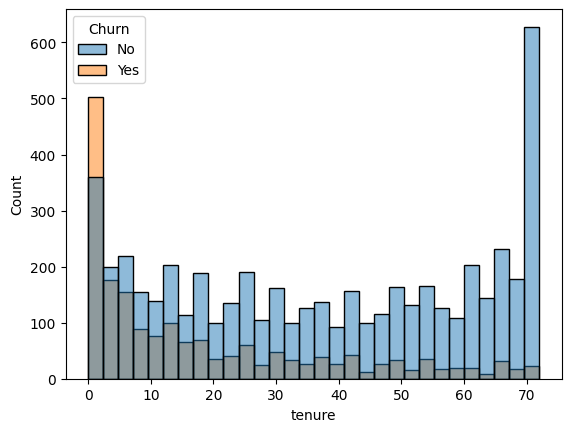

In [31]:
# Tenure
sns.histplot(data=df, x='tenure', hue='Churn', bins=30)
plt.savefig("tenure_churn.png")

In [32]:
# Creating Groups
df['tenure_group'] = pd.cut(df['tenure'],
                           bins=[0,12,24,48,72],
                           labels=['0-1yr','1-2yr','2-4yr','4-6yr'])

<Axes: xlabel='tenure_group', ylabel='count'>

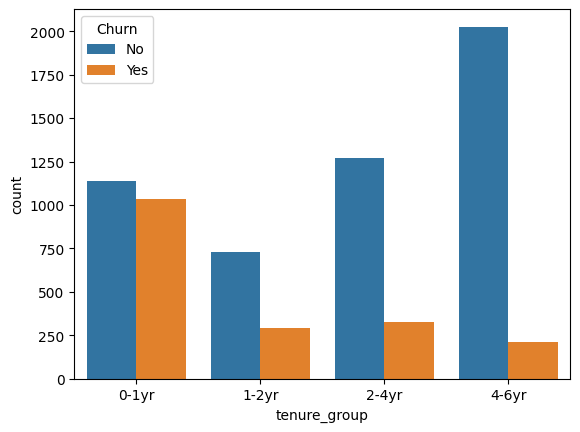

In [33]:
sns.countplot(data=df, x='tenure_group', hue='Churn')

- Customers with shorter tenure show higher churn rates  
- Long-term customers are more stable and less likely to churn  
- Improving onboarding and early engagement can reduce churn among new users  

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

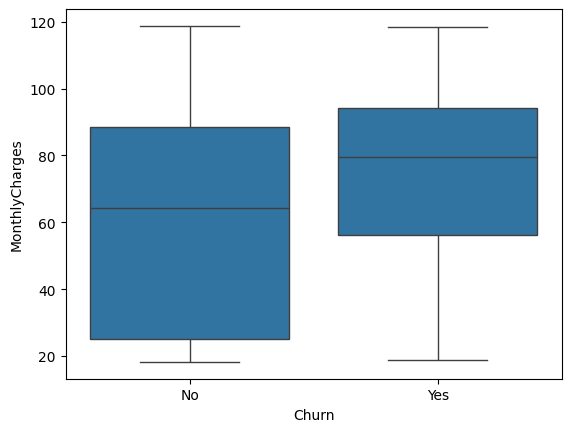

In [34]:
# Monthly Charges
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')

- Customers with higher monthly charges tend to churn more  
- This suggests pricing or perceived value issues  
- Reviewing pricing strategies or offering better value can help reduce churn  

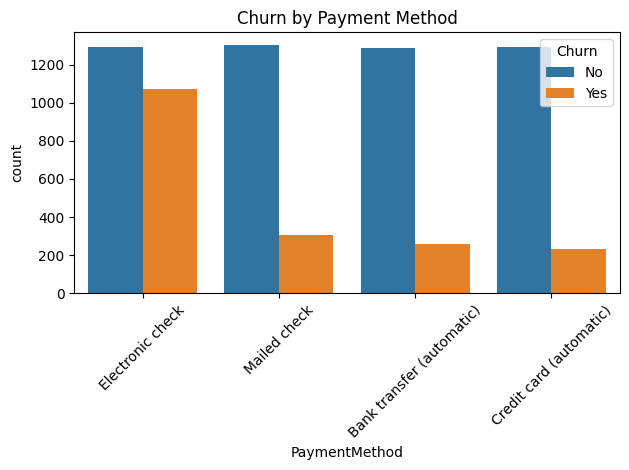

In [35]:
# Payment Method
sns.countplot(data=df, x='PaymentMethod', hue='Churn')

plt.xticks(rotation=45)   # rotate labels
plt.title("Churn by Payment Method")
plt.tight_layout()
plt.show()

- Certain payment methods (like electronic check) show higher churn rates  
- Payment experience may influence customer satisfaction  
- Improving payment convenience could help improve retention  

In [36]:
# Combined Features
combined = pd.crosstab([df['Contract'], df['InternetService']],
            df['Churn'], normalize='index') * 100
combined

Churn                                  No        Yes
Contract       InternetService                      
Month-to-month DSL              67.784137  32.215863
               Fiber optic      45.394737  54.605263
               No               81.106870  18.893130
One year       DSL              90.701754   9.298246
               Fiber optic      80.705009  19.294991
               No               97.527473   2.472527
Two year       DSL              98.089172   1.910828
               Fiber optic      92.773893   7.226107
               No               99.216301   0.783699

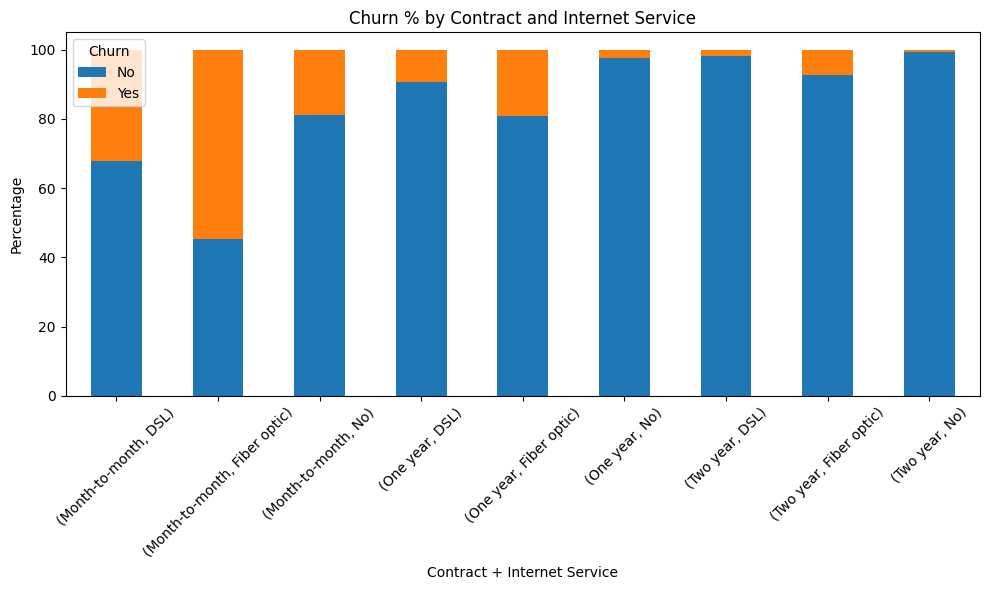

In [37]:
combined.plot(kind='bar', stacked=True, figsize=(10,6))

plt.title("Churn % by Contract and Internet Service")
plt.ylabel("Percentage")
plt.xlabel("Contract + Internet Service")

plt.legend(title="Churn")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("combined_churn.png")
plt.show()

- Customers with month-to-month contracts and fiber optic service show the highest churn (~54.6%), making them the most vulnerable segment  
- In contrast, long-term contracts (one-year and two-year) significantly reduce churn across all service types, especially for non-internet users (~0.7–2.5%)  
- Fiber optic users consistently show higher churn compared to DSL, particularly under short-term contracts  
- This indicates that both contract type and internet service together strongly influence churn behavior  
- Targeting month-to-month fiber users with retention strategies should be a top priority  

# Final Insights and Recommendations

### High-Risk Customer Profile

Customers most likely to churn have the following characteristics:

- Month-to-month contract users  
- Fiber optic internet service users  
- High monthly charges  
- Low tenure (new customers)  
- No TechSupport or OnlineSecurity services  
- Senior citizens  

### Key Insights

- Contract type is the strongest driver of churn, with month-to-month users showing ~42% churn  
- TechSupport and OnlineSecurity significantly reduce churn (~2–3x lower)  
- Fiber optic users have higher churn compared to DSL users  
- Customers with higher monthly charges are more likely to churn  
- New customers (low tenure) are at higher risk of leaving  

## Recommendations

- Encourage customers to switch to long-term contracts through discounts or incentives  
- Bundle TechSupport and OnlineSecurity services with plans to improve retention  
- Investigate and improve Fiber optic service experience (pricing or quality issues)  
- Focus on onboarding and engagement strategies for new customers  
- Target high-risk segments (monthly + fiber users) with personalized retention offers  

### Conclusion

Churn is driven by a combination of contract type, service usage, and customer engagement.  
Targeted retention strategies focusing on high-risk segments can significantly reduce churn and improve customer lifetime value.